In [20]:
#inputs
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd
import seaborn as sns



In [21]:
#run prediction code -> sbatch predict.sh
#outputs should be
#chrom	mid	embedding_id	predicted_counts	target_counts
#chr22	tensor(16601530)	AG10697	82.31743432418034	11.067932097548955

In [22]:
df = pd.read_table('/home/mbrannon/output.tsv')

In [23]:
df

,chrom,mid,embedding_id,predicted_counts,target_counts
0,chr22,tensor(16601530),AG10697,82.317434,11.067932
1,chr22,tensor(16774792),AG10697,51.184257,35.067931
2,chr22,tensor(17121164),AG10697,31.998422,105.067930
3,chr22,tensor(17121463),AG10697,133.099445,246.067939
4,chr22,tensor(17159017),AG10697,101.034478,177.067939
...,...,...,...,...,...
705093,chr22,tensor(46117132),AG96530,9.123122,12.094740
705094,chr9,tensor(133429626),AG96530,10.925798,8.094740
705095,chr22,tensor(50300804),AG96530,21.072324,5.094740
705096,chr9,tensor(77020055),AG96530,50.944711,8.094740


In [24]:
# Drop rows with any NaNs in the specified columns
df = df.dropna(subset=["chrom", "mid", "embedding_id", "predicted_counts", "target_counts"])


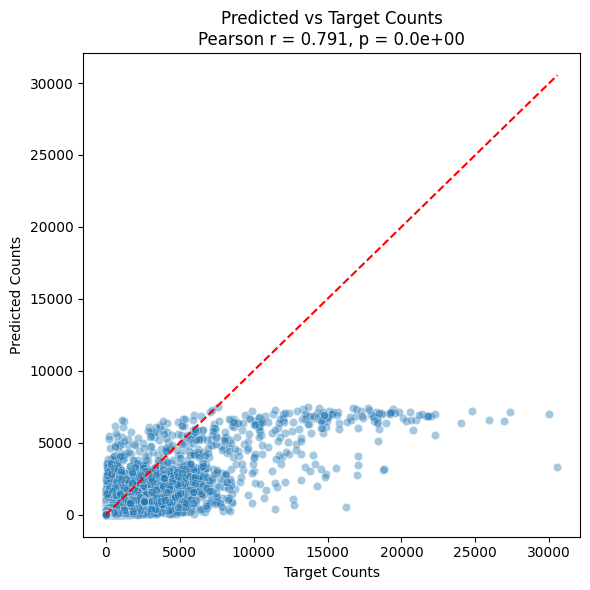

In [25]:
# Calculate overall Pearson

r, p = pearsonr(df["predicted_counts"], df["target_counts"])

# Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x="target_counts", y="predicted_counts", data=df, alpha=0.4)
plt.title(f"Predicted vs Target Counts\nPearson r = {r:.3f}, p = {p:.1e}")
plt.xlabel("Target Counts")
plt.ylabel("Predicted Counts")
plt.plot([df["target_counts"].min(), df["target_counts"].max()],
         [df["target_counts"].min(), df["target_counts"].max()],
         'r--')
plt.tight_layout()
plt.show()


/tmp/ipykernel_13176/1721882356.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["log_predicted"] = np.log1p(df["predicted_counts"])
/tmp/ipykernel_13176/1721882356.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["log_target"] = np.log1p(df["target_counts"])


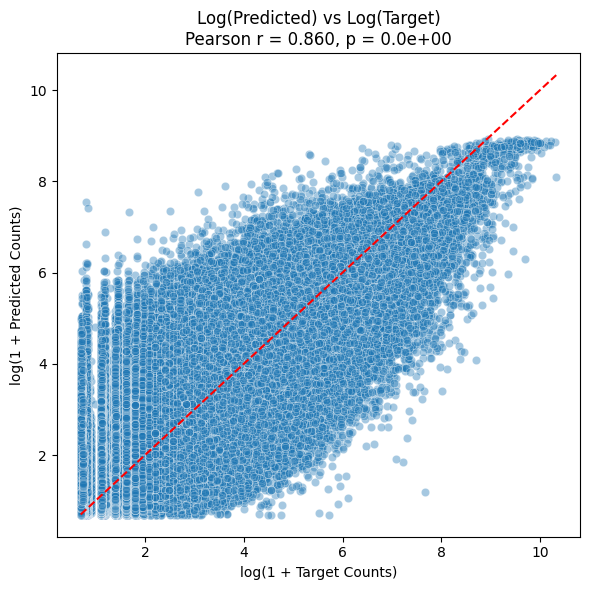

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Apply log transformation (handles 0s safely)
df["log_predicted"] = np.log1p(df["predicted_counts"])
df["log_target"] = np.log1p(df["target_counts"])

# Calculate Pearson correlation in log-space
r, p = pearsonr(df["log_predicted"], df["log_target"])

# Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x="log_target", y="log_predicted", data=df, alpha=0.4)
plt.title(f"Log(Predicted) vs Log(Target)\nPearson r = {r:.3f}, p = {p:.1e}")
plt.xlabel("log(1 + Target Counts)")
plt.ylabel("log(1 + Predicted Counts)")
plt.plot([df["log_target"].min(), df["log_target"].max()],
         [df["log_target"].min(), df["log_target"].max()],
         'r--')
plt.tight_layout()
plt.show()


In [27]:
# Calculate Pearson correlation for each embedding_id group, and include the count of samples per group
grouped_by_sample = (
    df.groupby("embedding_id")
    .apply(lambda g: pearsonr(g["log_predicted"], g["log_target"])[0])  # Compute Pearson correlation
    .reset_index(name="pearson_r")
)

# Add a column with the count of samples per embedding_id group
grouped_by_sample['sample_count'] = df.groupby("embedding_id").size().reset_index(name="sample_count")['sample_count']

# Check the first few rows to confirm
print(grouped_by_sample.head())


  embedding_id  pearson_r  sample_count
0      AG10697   0.771220          4042
1      AG15858   0.746848          4422
2      AG58676   0.912302          1023
3      AG58686   0.905378          1154
4      AG58700   0.904877          1092


In [29]:
rep_embed = pd.read_table('/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/representative_samples_by_annotation_stratified.tsv')

ag_want = rep_embed[rep_embed['extended_annotation'] == 'Erythroid'].sample_id.values


In [33]:
df_ery = df[df['embedding_id'].isin(ag_want)]

In [34]:
df_ery

,chrom,mid,embedding_id,predicted_counts,target_counts,log_predicted,log_target
652489,chr22,tensor(16601305),AG95458,76.655751,62.027752,4.352286,4.143575
652490,chr22,tensor(16603372),AG95458,10.076059,4.027755,2.404786,1.614973
652491,chr22,tensor(16774792),AG95458,21.804777,23.027754,3.126970,3.179210
652492,chr22,tensor(16783934),AG95458,8.312192,7.027755,2.231324,2.082905
652493,chr22,tensor(16955857),AG95458,18.133059,12.027754,2.951418,2.567082
...,...,...,...,...,...,...,...
661050,chr9,tensor(135907700),AG95458,168.420416,319.027754,5.132383,5.768408
661051,chr22,tensor(48489491),AG95458,6.711976,1.027755,2.042774,0.706929
661052,chr22,tensor(48489517),AG95458,9.298982,1.027755,2.332045,0.706929
661053,chr9,tensor(136095547),AG95458,20.753212,2.027755,3.079761,1.107821


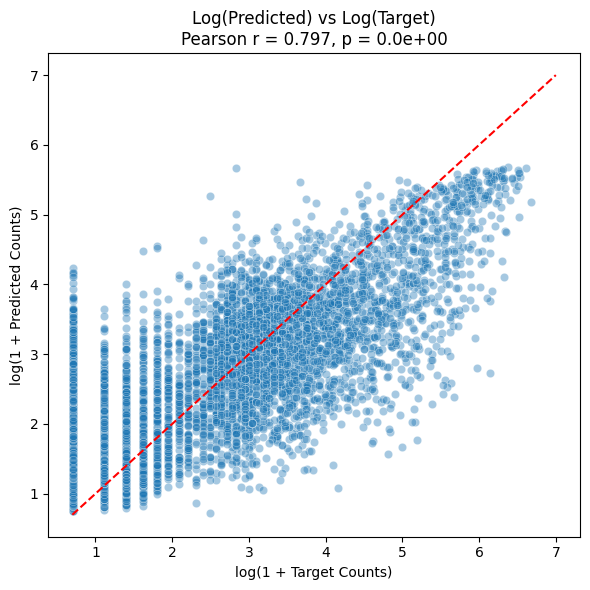

In [41]:
# Apply log transformation (handles 0s safely)


pred = df_ery["log_predicted"]
targ = df_ery["log_target"]

# Calculate Pearson correlation in log-space
r, p = pearsonr(targ, pred)

# Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x="log_target", y="log_predicted", data=df_ery, alpha=0.4)
plt.title(f"Log(Predicted) vs Log(Target)\nPearson r = {r:.3f}, p = {p:.1e}")
plt.xlabel("log(1 + Target Counts)")
plt.ylabel("log(1 + Predicted Counts)")
plt.plot([df["log_target"].min(), 7],
         [df["log_target"].min(), 7],
         'r--')
plt.tight_layout()
plt.show()


/tmp/ipykernel_13176/2112501806.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


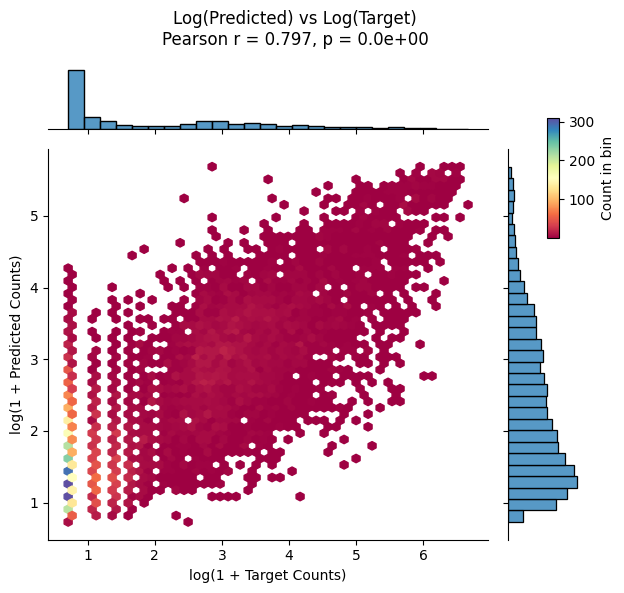

In [40]:
# Apply log transformation (handles 0s safely)

plot = sns.jointplot(
    x="log_target", 
    y="log_predicted", 
    data=df_ery,
    kind='hex',
    cmap="Spectral",
    height=6,
    gridsize=50,
    mincnt=1
)

# Add title with Pearson r and p-value
plot.fig.suptitle(f"Log(Predicted) vs Log(Target)\nPearson r = {r:.3f}, p = {p:.1e}")

# Axis labels
plot.set_axis_labels("log(1 + Target Counts)", "log(1 + Predicted Counts)")

# Custom colorbar position
cbar_ax = plot.fig.add_axes([.92, .6, .02, .2])
plt.colorbar(plot.ax_joint.collections[0], cax=cbar_ax, label="Count in bin")

plt.tight_layout()
plt.show()


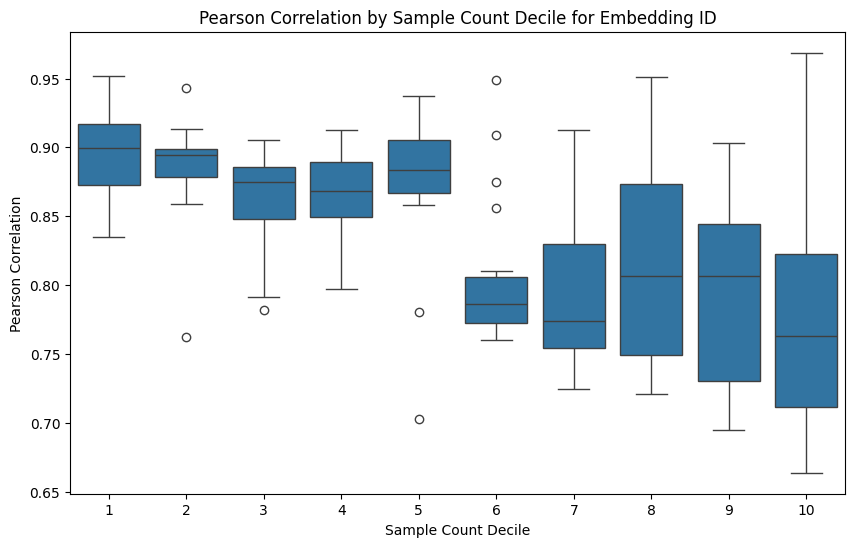

In [21]:
# Create deciles for sample count
grouped_by_sample['sample_count_decile'] = pd.qcut(grouped_by_sample['sample_count'], 10, labels=False) + 1

# Create a box plot of the Pearson correlation, grouped by sample count decile
plt.figure(figsize=(10, 6))
sns.boxplot(x="sample_count_decile", y="pearson_r", data=grouped_by_sample)
plt.title('Pearson Correlation by Sample Count Decile for Embedding ID')
plt.xlabel('Sample Count Decile')
plt.ylabel('Pearson Correlation')
plt.show()


In [25]:
deciles, bin_edges = pd.qcut(grouped_by_sample['sample_count'], 10, retbins=True, labels=False)
print("Decile bin edges:", bin_edges)


Decile bin edges: [  227.    304.9   347.6   411.4   955.8  1920.5  3309.6  4541.5  5692.2
  7702.7 33142. ]


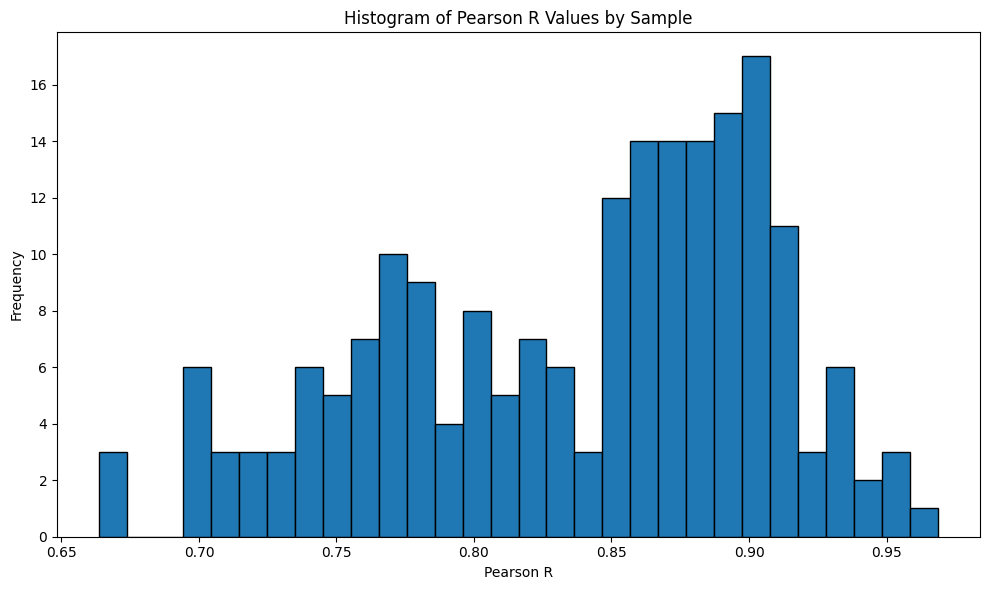

In [22]:
# Assuming 'grouped_by_sample' contains the 'pearson_r' column
plt.figure(figsize=(10, 6))

# Plotting the histogram
plt.hist(grouped_by_sample['pearson_r'], bins=30, edgecolor='black')

# Adding labels and title
plt.title("Histogram of Pearson R Values by Sample")
plt.xlabel("Pearson R")
plt.ylabel("Frequency")

# Show the plot
plt.tight_layout()
plt.show()


In [23]:
# Filter rows with pearson_r < 0.6
filtered_samples = grouped_by_sample[grouped_by_sample['pearson_r'] < 0.7]

# Display the filtered samples
print(filtered_samples)


    embedding_id  pearson_r  sample_count  sample_count_decile
95       AG80380   0.673087         27646                   10
110      AG80583   0.698736          7370                    9
112      AG80601   0.669120          8092                   10
130      AG80762   0.694788          6428                    9
132      AG80781   0.663655          8663                   10
133      AG80785   0.698431          8652                   10
135      AG80854   0.697240          6817                    9


In [3]:
import pandas as pd

# Load the file
df = pd.read_csv("/home/mbrannon/tmp/variant_pred_new_8_1.tsv", sep="\t")

# Rename the columns
df = df.rename(columns={
    "predicted_counts": "predicted_lfc",
    "target_counts": "target_lfc"
})

# (Optional) Save the updated DataFrame back to file
df.to_csv("/home/mbrannon/tmp/variant_pred_new_8_1_renamed.tsv", sep="\t", index=False)


/tmp/ipykernel_13176/2232351966.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


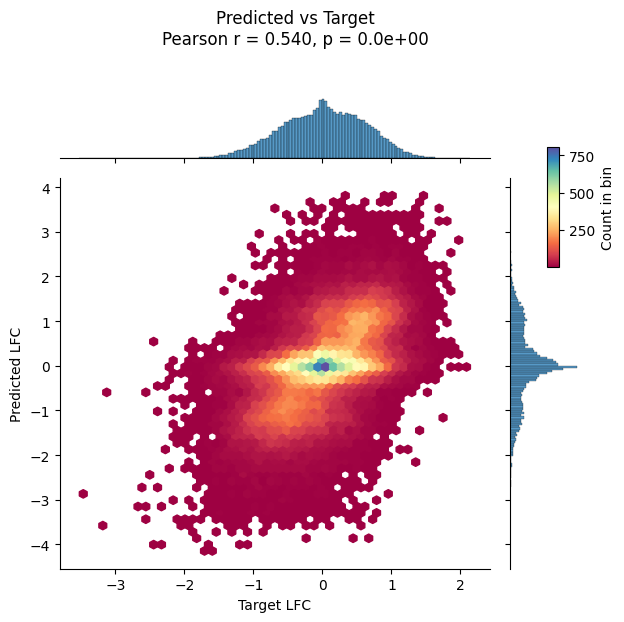

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

df_old = pd.read_table('/home/mbrannon/tmp/variant_pred_new_8_1.tsv')

# Pearson correlation
r, p = pearsonr(df_old["predicted_lfc"], df_old["target_lfc"])

# Create joint hex plot with more bins, custom color palette, and mincnt
plot = sns.jointplot(
    x="predicted_lfc",
    y="target_lfc",
    data=df_old,
    kind='hex',
    cmap="Spectral",  # Change color map for more range
    height=6,
    gridsize=50,  # More bins for finer detail
    mincnt=1  # Ensures bins with counts are shown, even if sparse
)

# Add title with Pearson r and p-value
plot.fig.suptitle(f"Predicted vs Target\nPearson r = {r:.3f}, p = {p:.1e}", y=1.03)

# Adjust axes labels
plot.set_axis_labels("Target LFC", "Predicted LFC")

# Custom colorbar position
cbar_ax = plot.fig.add_axes([.92, .6, .02, .2])  # right side
plt.colorbar(plot.ax_joint.collections[0], cax=cbar_ax, label="Count in bin")

plt.tight_layout()
plt.show()


In [10]:
df

,sample_id,chr,pos,ref,alt,predicted_lfc,target_lfc
0,AG6445,chr7,55110464,C,T,0.580678,-0.566254
1,AG58832,chr12,17194845,G,A,-0.420049,-0.399059
2,AG72438,chr2,219526450,G,A,-0.350937,0.399059
3,AG96366,chr9,105447930,A,C,-0.397076,-0.462510
4,AG96467,chr5,123438538,C,A,-1.068937,-1.210389
...,...,...,...,...,...,...,...
49523707,AG81802,chr12,95918907,C,A,0.450008,0.010263
49523708,AG68557,chr8,130675757,A,G,-0.246546,-0.658655
49523709,AG71488,chr9,101533486,C,T,0.638739,0.444798
49523710,AG6245,chr2,128190320,T,C,0.011512,0.000000


/tmp/ipykernel_13176/225601220.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


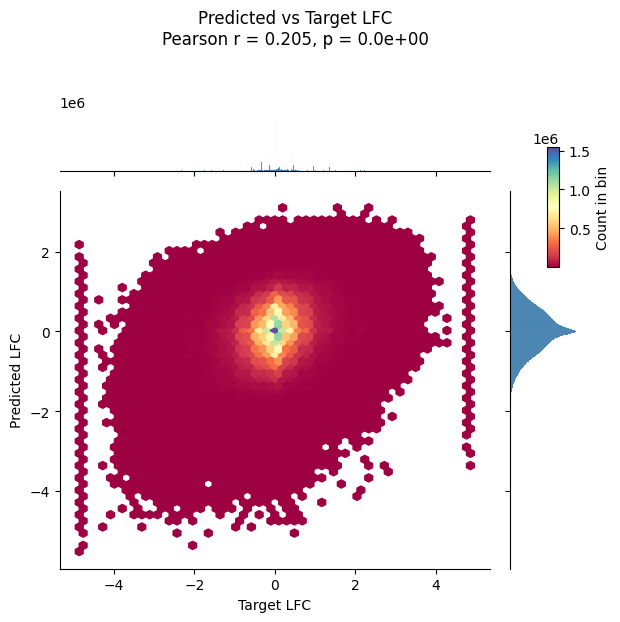

In [6]:
df = pd.read_csv("/home/mbrannon/tmp/variant_preds/variant_predictions_JUL28_3_a100_clip_density.bed", sep="\t")

# Pearson correlation
r, p = pearsonr(df["predicted_lfc"], df["target_lfc"])

# Plot using seaborn jointplot with hex bins
plot = sns.jointplot(
    x="target_lfc",
    y="predicted_lfc",
    data=df,
    kind='hex',
    cmap="Spectral",
    height=6,
    gridsize=50,
    mincnt=1
)

# Add title with Pearson r and p-value
plot.fig.suptitle(f"Predicted vs Target LFC\nPearson r = {r:.3f}, p = {p:.1e}", y=1.03)

# Axis labels
plot.set_axis_labels("Target LFC", "Predicted LFC")

# Custom colorbar position
cbar_ax = plot.fig.add_axes([.92, .6, .02, .2])
plt.colorbar(plot.ax_joint.collections[0], cax=cbar_ax, label="Count in bin")

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd
from scipy.stats import pearsonr

# Load data
df = pd.read_csv("/home/mbrannon/tmp/variant_preds/variant_predictions_JUL28_3_a100_clip_density.bed", sep="\t")

# Group by sample_id and compute Pearson r for each group
correlation_df = df.groupby("sample_id").apply(
    lambda g: pd.Series(pearsonr(g["predicted_lfc"], g["target_lfc"]), index=["r", "p"])
).reset_index()

print(correlation_df.head())


  sample_id         r             p
0   AG10031  0.090159  2.835315e-07
1   AG10032  0.115224  6.299985e-14
2   AG10033  0.096327  4.823215e-10
3   AG10034  0.060749  7.357052e-04
4   AG10036  0.122192  2.388020e-17


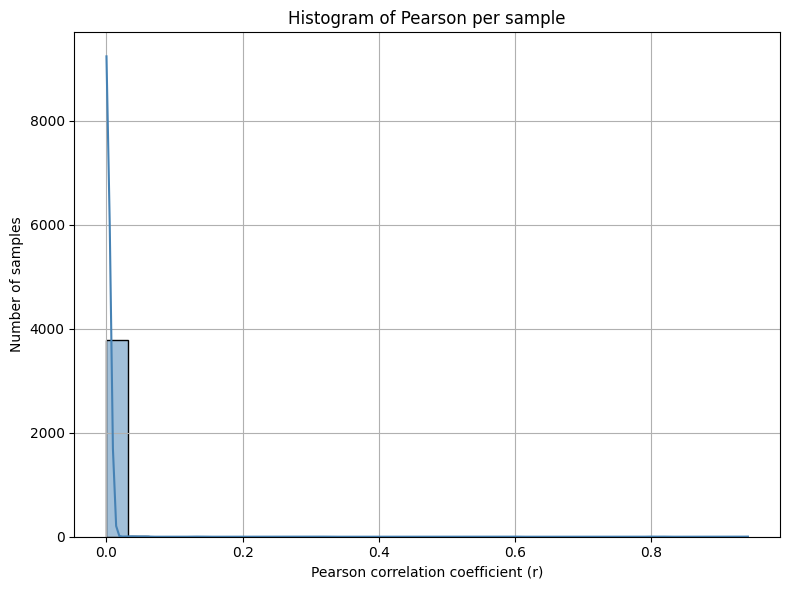

In [18]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("/home/mbrannon/tmp/variant_preds/variant_predictions_JUL28_3_a100_clip_density.bed", sep="\t")

# Compute Pearson r per sample_id
correlation_df = df.groupby("sample_id").apply(
    lambda g: pd.Series(pearsonr(g["predicted_lfc"], g["target_lfc"]), index=["r", "p"])
).reset_index()

# Plot histogram of Pearson r-values
plt.figure(figsize=(8, 6))
sns.histplot(correlation_df["p"], bins=30, kde=True, color="steelblue")

plt.title("Histogram of Pearson per sample")
plt.xlabel("Pearson correlation coefficient (r)")
plt.ylabel("Number of samples")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import h5py
import os
from pathlib import Path

# Path to the input .bed.gz file
input_path = "/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v4/output/non_aggregated.extended_annotation_id.bed.gz"
output_path = "/home/mbrannon/tmp/sample_data.h5"

# Read the file while skipping comment lines
df = pd.read_csv(input_path, sep="\t")

df_small = df[[
    "#chr",
    "start",
    "ref",
    "alt",
    "ref_counts",
    "alt_counts",
    "BAD",
    "sample_id",
    "logit_es"
]].copy()

df_small.rename(columns={"start": "pos",'#chr':'chrom'}, inplace=True)
df_small["total_counts"] = df_small["ref_counts"] + df_small["alt_counts"]

df_small = df_small[[
    "chrom", "pos", "ref", "alt",
    "ref_counts", "total_counts", "BAD",
    "sample_id", "logit_es"
]]

df_small


# Make sure output dir exists
output_dir = "/home/mbrannon/tmp/eval_samples"
os.makedirs(output_dir, exist_ok=True)

df_small = df_small.sample(frac=1, random_state=42).reset_index(drop=True)
split_dfs = np.array_split(df_small, 100)


def write_chunk_to_h5(df, chunk_id, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    out_path = output_dir / f"{chunk_id}.h5"

    # Create special dtype for variable-length strings
    str_dtype = h5py.string_dtype(encoding='utf-8')
    
    assert set(
        [
            "chrom",
            "pos",
            "ref",
            "alt",
            "ref_counts",
            "total_counts",
            "BAD",
            "logit_es",
            "sample_id"
        ]
    ).issubset(df.columns)

    with h5py.File(out_path, "w") as f:
        # Create datasets directly at the root level (no group header)
        f.create_dataset("chrom", data=df["chrom"].astype(str).values, dtype=str_dtype)
        f.create_dataset("pos", data=df["pos"].astype(np.int32).values)
        f.create_dataset("ref", data=df["ref"].astype(str).values, dtype=str_dtype)
        f.create_dataset("alt", data=df["alt"].astype(str).values, dtype=str_dtype)
        f.create_dataset("ref_counts", data=df["ref_counts"].astype(np.float32).values)
        f.create_dataset("total_counts", data=df["total_counts"].astype(np.float32).values)
        f.create_dataset("BAD", data=df["BAD"].astype(np.float32).values)
        f.create_dataset("logit_es", data=df["logit_es"].astype(np.float32).values)
        f.create_dataset("sample_id", data=df["sample_id"].astype(str).values, dtype=str_dtype)

    print(f"Wrote: {out_path}")



In [ ]:
output_dir = "/home/mbrannon/tmp/eval_samples"
os.makedirs(output_dir, exist_ok=True)

# Output directory
output_dir = "/home/mbrannon/tmp/eval_samples"
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Run the function for each chunk
for i, chunk in enumerate(split_dfs):
    write_chunk_to_h5(chunk, i, output_dir)

#### shape

In [2]:
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo

from vinson.interpretation import dinucleotide_shuffle, force_strict_ohe
from vinson.model import _Exp

In [ ]:
from tangermeme.predict import predict
from tangermeme.product import apply_pairwise

In [ ]:
_X = force_strict_ohe(X_seq[i : i + 1].clone())

Y_embed = X_embed[i : i + 1].clone()

# Run DeepLIFT/SHAP
attrs = deep_lift_shap(
    model,
    _X,
    args=(Y_embed,),
    model_kwargs=dict(exp=True),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

Y_embed_rand = torch.tensor(dataset.embeddings_df.iloc[:, 5].values[np.newaxis,:]).to(torch.float32)

attrs_rand = deep_lift_shap(
    model,
    _X,
    args=(Y_embed_rand,),
    model_kwargs=dict(exp=True),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

In [ ]:
from tangermeme.plot import plot_logo

fig, ax = plt.subplots()
plot_logo(attrs[0][:, 550:-500], ax=ax)
ax.set_ylim(top=0.075)
fig.set_size_inches(15, 1.5)

In [ ]:
#get only real scores
real_scores = (X_seqs * attrs).sum(axis=1)

In [ ]:
X_attr.shape

In [ ]:
real_scores.shape

In [ ]:
#uses tangermeme seqlet calculation
from tangermeme.seqlet import recursive_seqlets

seqlets = recursive_seqlets(X, additional_flanks=0, threshold=0.01)


In [ ]:
from tangermeme.io import read_meme
from tangermeme.annotate import annotate_seqlets

meme_file = '/home/jvierstra/public_html/projects/motif-clustering-v2.1beta/all.dbs.meme'


In [ ]:
motifs = read_meme(meme_file)
motif_idxs, motif_pvalues = annotate_seqlets(X_attr, seqlets, motifs)

In [ ]:
motifs = read_meme(meme_file)
motif_names = numpy.array(list(motifs.keys()))


y = count_annotations((seqlets['example_idx'], motif_idxs[:, 0]))


In [ ]:
# If y is sparse and fits in memory as dense
motif_counts = y.to_dense().sum(dim=0)  # sum over rows (examples) → shape: [num_motifs]


In [ ]:
motif_count_list = [(count.item(), idx) for idx, count in enumerate(motif_counts)]
# Optionally sort by count descending
motif_count_list.sort(reverse=True)


In [ ]:
motifs = read_meme(meme_file)
index_to_name = [k for k, v in motifs.items()]
records = []
for count, idx in motif_count_list:
    name = index_to_name[idx]
    records.append((count, idx, name))


In [ ]:


# records: list of tuples (count, idx, name)
motif_counts_df = pd.DataFrame(records, columns=["count", "motif_index", "motif_name"])

# Optional: sort by count descending
motif_counts_df  = motif_counts_df.sort_values(by="count", ascending=False).reset_index(drop=True)

